<a href="https://colab.research.google.com/github/gogetafterit/spacex_falcon9_analysis/blob/main/SpaceX_Falcon__9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import requests
import pandas as pd
import numpy as np
import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

def getBoosterVersion(data):
    for x in data['rocket']:
        if x:
            response = requests.get("https://api.spacexdata.com/v4/rockets/"+str(x)).json()
            BoosterVersion.append(response['name'])

def getLaunchSite(data):
    for x in data['launchpad']:
        if x:
            response = requests.get("https://api.spacexdata.com/v4/launchpads/"+str(x)).json()
            Longitude.append(response['longitude'])
            Latitude.append(response['latitude'])
            LaunchSite.append(response['name'])

def getPayloadData(data):
    for load in data['payloads']:
        if load:
            response = requests.get("https://api.spacexdata.com/v4/payloads/"+load).json()
            PayloadMass.append(response['mass_kg'])
            Orbit.append(response['orbit'])

def getCoreData(data):
    for core in data['cores']:
        if core['core'] is not None:
            response = requests.get("https://api.spacexdata.com/v4/cores/"+core['core']).json()
            Block.append(response['block'])
            ReusedCount.append(response['reuse_count'])
            Serial.append(response['serial'])
        else:
            Block.append(None)
            ReusedCount.append(None)
            Serial.append(None)

        Outcome.append(str(core['landing_success']) + ' ' + str(core['landing_type']))
        Flights.append(core['flight'])
        GridFins.append(core['gridfins'])
        Reused.append(core['reused'])
        Legs.append(core['legs'])
        LandingPad.append(core['landpad'])

static_json_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json'
response = requests.get(static_json_url)

data = pd.json_normalize(response.json())

data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]
data = data[data['cores'].map(len) == 1]
data = data[data['payloads'].map(len) == 1]

data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])
data['date'] = pd.to_datetime(data['date_utc']).dt.date

data = data[data['date'] <= datetime.date(2020, 11, 13)]

BoosterVersion, PayloadMass, Orbit = [], [], []
LaunchSite, Outcome, Flights = [], [], []
GridFins, Reused, Legs, LandingPad = [], [], [], []
Block, ReusedCount, Serial = [], [], []
Longitude, Latitude = [], []

getBoosterVersion(data)
getLaunchSite(data)
getPayloadData(data)
getCoreData(data)

launch_dict = {
    'FlightNumber': list(data['flight_number']),
    'Date': list(data['date']),
    'BoosterVersion': BoosterVersion,
    'PayloadMass': PayloadMass,
    'Orbit': Orbit,
    'LaunchSite': LaunchSite,
    'Outcome': Outcome,
    'Flights': Flights,
    'GridFins': GridFins,
    'Reused': Reused,
    'Legs': Legs,
    'LandingPad': LandingPad,
    'Block': Block,
    'ReusedCount': ReusedCount,
    'Serial': Serial,
    'Longitude': Longitude,
    'Latitude': Latitude
}

df = pd.DataFrame(launch_dict)

data_falcon9 = df[df['BoosterVersion'] == 'Falcon 9'].copy()
data_falcon9.loc[:, 'FlightNumber'] = list(range(1, data_falcon9.shape[0] + 1))

mean_payload_mass = data_falcon9['PayloadMass'].mean()
data_falcon9['PayloadMass'] = data_falcon9['PayloadMass'].replace(np.nan, mean_payload_mass)

print(data_falcon9.isnull().sum())

data_falcon9.to_csv('dataset_part_1.csv', index=False)
print(data_falcon9.head())

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
dtype: int64
   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
4             1  2010-06-04       Falcon 9  6123.547647   LEO  CCSFS SLC 40   
5             2  2012-05-22       Falcon 9   525.000000   LEO  CCSFS SLC 40   
6             3  2013-03-01       Falcon 9   677.000000   ISS  CCSFS SLC 40   
7             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
8             5  2013-12-03       Falcon 9  3170.000000   GTO  CCSFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
4    None None        1     False   False  False       None    1.0   
5    None None 

In [ ]:

import requests
import pandas as pd
import numpy as np
import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

BoosterVersion, PayloadMass, Orbit = [], [], []
LaunchSite, Outcome, Flights = [], [], []
GridFins, Reused, Legs, LandingPad = [], [], [], []
Block, ReusedCount, Serial = [], [], []
Longitude, Latitude = [], []

def getBoosterVersion(data):
    for x in data['rocket']:
        if x:
            response = requests.get("https://api.spacexdata.com/v4/rockets/"+str(x)).json()
            BoosterVersion.append(response['name'])

def getLaunchSite(data):
    for x in data['launchpad']:
        if x:
            response = requests.get("https://api.spacexdata.com/v4/launchpads/"+str(x)).json()
            Longitude.append(response['longitude'])
            Latitude.append(response['latitude'])
            LaunchSite.append(response['name'])

def getPayloadData(data):
    for load in data['payloads']:
        if load:
            response = requests.get("https://api.spacexdata.com/v4/payloads/"+load).json()
            PayloadMass.append(response['mass_kg'])
            Orbit.append(response['orbit'])

def getCoreData(data):
    for core in data['cores']:
        if core['core'] is not None:
            response = requests.get("https://api.spacexdata.com/v4/cores/"+core['core']).json()
            Block.append(response['block'])
            ReusedCount.append(response['reuse_count'])
            Serial.append(response['serial'])
        else:
            Block.append(None)
            ReusedCount.append(None)
            Serial.append(None)

        Outcome.append(str(core['landing_success']) + ' ' + str(core['landing_type']))
        Flights.append(core['flight'])
        GridFins.append(core['gridfins'])
        Reused.append(core['reused'])
        Legs.append(core['legs'])
        LandingPad.append(core['landpad'])

static_json_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json'
response = requests.get(static_json_url)
data = pd.json_normalize(response.json())

data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]
data = data[data['cores'].map(len) == 1]
data = data[data['payloads'].map(len) == 1]

data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])
data['date'] = pd.to_datetime(data['date_utc']).dt.date

data = data[data['date'] <= datetime.date(2020, 11, 13)]

print("Fetching data from API...")
getBoosterVersion(data)
getLaunchSite(data)
getPayloadData(data)
getCoreData(data)

launch_dict = {
    'FlightNumber': list(data['flight_number']),
    'Date': list(data['date']),
    'BoosterVersion': BoosterVersion,
    'PayloadMass': PayloadMass,
    'Orbit': Orbit,
    'LaunchSite': LaunchSite,
    'Outcome': Outcome,
    'Flights': Flights,
    'GridFins': GridFins,
    'Reused': Reused,
    'Legs': Legs,
    'LandingPad': LandingPad,
    'Block': Block,
    'ReusedCount': ReusedCount,
    'Serial': Serial,
    'Longitude': Longitude,
    'Latitude': Latitude
}

df = pd.DataFrame(launch_dict)

data_falcon9 = df[df['BoosterVersion'] == 'Falcon 9'].copy()
data_falcon9.loc[:, 'FlightNumber'] = list(range(1, data_falcon9.shape[0] + 1))

mean_payload_mass = data_falcon9['PayloadMass'].mean()
data_falcon9['PayloadMass'] = data_falcon9['PayloadMass'].replace(np.nan, mean_payload_mass)

print("\nMissing values check:")
print(data_falcon9.isnull().sum())

data_falcon9.to_csv('dataset_part_1.csv', index=False)
print("\nData saved to dataset_part_1.csv")
print(data_falcon9.head())

Fetching data from API...

Missing values check:
FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
dtype: int64

Data saved to dataset_part_1.csv
   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
4             1  2010-06-04       Falcon 9  6123.547647   LEO  CCSFS SLC 40   
5             2  2012-05-22       Falcon 9   525.000000   LEO  CCSFS SLC 40   
6             3  2013-03-01       Falcon 9   677.000000   ISS  CCSFS SLC 40   
7             4  2013-09-29       Falcon 9   500.000000    PO   VAFB SLC 4E   
8             5  2013-12-03       Falcon 9  3170.000000   GTO  CCSFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
4 

In [ ]:

# 1. Install and Import Libraries
!pip install requests pandas numpy

import requests
import pandas as pd
import numpy as np
import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

# 2. Define Helper Functions
def getBoosterVersion(data):
    for x in data['rocket']:
       if x:
        response = requests.get("https://api.spacexdata.com/v4/rockets/"+str(x)).json()
        BoosterVersion.append(response['name'])

def getLaunchSite(data):
    for x in data['launchpad']:
       if x:
         response = requests.get("https://api.spacexdata.com/v4/launchpads/"+str(x)).json()
         Longitude.append(response['longitude'])
         Latitude.append(response['latitude'])
         LaunchSite.append(response['name'])

def getPayloadData(data):
    for load in data['payloads']:
       if load:
        response = requests.get("https://api.spacexdata.com/v4/payloads/"+load).json()
        PayloadMass.append(response['mass_kg'])
        Orbit.append(response['orbit'])

def getCoreData(data):
    for core in data['cores']:
            if core['core'] != None:
                response = requests.get("https://api.spacexdata.com/v4/cores/"+core['core']).json()
                Block.append(response['block'])
                ReusedCount.append(response['reuse_count'])
                Serial.append(response['serial'])
            else:
                Block.append(None)
                ReusedCount.append(None)
                Serial.append(None)
            Outcome.append(str(core['landing_success'])+' '+str(core['landing_type']))
            Flights.append(core['flight'])
            GridFins.append(core['gridfins'])
            Reused.append(core['reused'])
            Legs.append(core['legs'])
            LandingPad.append(core['landpad'])

# 3. Data Extraction
static_json_url='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json'
response = requests.get(static_json_url)
data = pd.json_normalize(response.json())

data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]
data = data[data['cores'].map(len)==1]
data = data[data['payloads'].map(len)==1]
data['cores'] = data['cores'].map(lambda x : x[0])
data['payloads'] = data['payloads'].map(lambda x : x[0])
data['date'] = pd.to_datetime(data['date_utc']).dt.date
data = data[data['date'] <= datetime.date(2020, 11, 13)]

BoosterVersion, PayloadMass, Orbit, LaunchSite, Outcome = [], [], [], [], []
Flights, GridFins, Reused, Legs, LandingPad = [], [], [], [], []
Block, ReusedCount, Serial, Longitude, Latitude = [], [], [], [], []

getBoosterVersion(data)
getLaunchSite(data)
getPayloadData(data)
getCoreData(data)

# 4. Construct Final Dataframe
launch_dict = {
    'FlightNumber': list(data['flight_number']),
    'Date': list(data['date']),
    'BoosterVersion': BoosterVersion,
    'PayloadMass': PayloadMass,
    'Orbit': Orbit,
    'LaunchSite': LaunchSite,
    'Outcome': Outcome,
    'Flights': Flights,
    'GridFins': GridFins,
    'Reused': Reused,
    'Legs': Legs,
    'LandingPad': LandingPad,
    'Block': Block,
    'ReusedCount': ReusedCount,
    'Serial': Serial,
    'Longitude': Longitude,
    'Latitude': Latitude
}

df = pd.DataFrame(launch_dict)

data_falcon9 = df[df['BoosterVersion'] == 'Falcon 9'].copy()
data_falcon9.loc[:,'FlightNumber'] = list(range(1, data_falcon9.shape[0]+1))

mean_mass = data_falcon9['PayloadMass'].mean()
data_falcon9['PayloadMass'] = data_falcon9['PayloadMass'].replace(np.nan, mean_mass)

data_falcon9.to_csv('dataset_part_1.csv', index=False)
print("Part 1 Complete: dataset_part_1.csv saved.")

Part 1 Complete: dataset_part_1.csv saved.


In [ ]:

import sys
import requests
from bs4 import BeautifulSoup
import unicodedata
import pandas as pd

def date_time(table_cells):
    return [data_time.strip() for data_time in list(table_cells.strings)][0:2]

def booster_version(table_cells):
    out=''.join([bv for i,bv in enumerate(table_cells.strings) if i%2==0][0:-1])
    return out

def landing_status(table_cells):
    try:
        out=[i for i in table_cells.strings][0]
    except:
        out="N/A"
    return out

def get_mass(table_cells):
    mass=unicodedata.normalize("NFKD", table_cells.text).strip()
    if mass:
        new_mass = mass[0:mass.find("kg")+2] if "kg" in mass else mass
    else:
        new_mass = "0"
    return new_mass

def extract_column_from_header(row):
    if (row.br): row.br.extract()
    if row.a: row.a.extract()
    if row.sup: row.sup.extract()
    column_name = ' '.join(row.contents)
    if not(column_name.strip().isdigit()):
        return column_name.strip()

url = "https://en.wikipedia.org/wiki/List_of_Falcon_9_and_Falcon_Heavy_launches"
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

response = requests.get(url, headers=headers)

if response.status_code == 200:
    print("Success: Wikipedia content retrieved.")
    soup = BeautifulSoup(response.text, "html.parser")

    html_tables = soup.find_all("table", class_="wikitable")

    if len(html_tables) > 2:
        first_launch_table = html_tables[2]
        column_names = []
        for th in first_launch_table.find_all('th'):
            name = extract_column_from_header(th)
            if name and len(name) > 0:
                column_names.append(name)

        launch_dict = {col: [] for col in column_names if col != 'Date and time ( )'}

        for key in ['Version Booster', 'Booster landing', 'Date', 'Time']:
            launch_dict[key] = []

        for table in soup.find_all('table', "wikitable plainrowheaders collapsible"):
            for rows in table.find_all("tr"):
                if rows.th and rows.th.string:
                    flight_number = rows.th.string.strip()
                    flag = flight_number.isdigit()
                else:
                    flag = False

                row = rows.find_all('td')
                if flag and len(row) >= 9:
                    launch_dict['Flight No.'].append(flight_number)

                    dt_list = date_time(row[0])
                    launch_dict['Date'].append(dt_list[0].strip(','))
                    launch_dict['Time'].append(dt_list[1])

                    bv = booster_version(row[1])
                    if not bv and row[1].a: bv = row[1].a.string
                    launch_dict['Version Booster'].append(bv)

                    launch_dict['Launch site'].append(row[2].get_text(strip=True))
                    launch_dict['Payload'].append(row[3].get_text(strip=True))
                    launch_dict['Payload mass'].append(get_mass(row[4]))
                    launch_dict['Orbit'].append(row[5].get_text(strip=True))

                    customer = row[6].get_text(strip=True)
                    launch_dict['Customer'].append(customer)

                    launch_dict['Launch outcome'].append(list(row[7].strings)[0].strip() if row[7].strings else "Unknown")
                    launch_dict['Booster landing'].append(landing_status(row[8]).strip())

        df = pd.DataFrame({k: pd.Series(v) for k, v in launch_dict.items()})
        df.to_csv('spacex_web_scraped.csv', index=False)
        print(f"Done! {len(df)} rows saved to spacex_web_scraped.csv")
        print(df.head())
    else:
        print("Error: Could not find the expected tables on the page.")
else:
    print(f"Connection Failed. Status Code: {response.status_code}.")

Success: Wikipedia content retrieved.
Done! 0 rows saved to spacex_web_scraped.csv
Empty DataFrame
Columns: [Flight No., Launch site, Payload, Payload mass, Orbit, Customer, Launch outcome, Version Booster, Booster landing, Date, Time]
Index: []


In [ ]:

import requests
from bs4 import BeautifulSoup
import pandas as pd
import unicodedata

def date_time(table_cells):
    return [data_time.strip() for data_time in list(table_cells.strings)][0:2]

def booster_version(table_cells):
    out=''.join([bv for i,bv in enumerate(table_cells.strings) if i%2==0][0:-1])
    return out

def get_mass(table_cells):
    mass=unicodedata.normalize("NFKD", table_cells.text).strip()
    return mass if mass else "0"

url = "https://en.wikipedia.org/wiki/List_of_Falcon_9_and_Falcon_Heavy_launches"
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

launch_dict = {
    "Flight No.": [], "Date": [], "Time": [], "Version Booster": [],
    "Launch site": [], "Payload": [], "Payload mass": [], "Orbit": [],
    "Customer": [], "Launch outcome": [], "Booster landing": []
}

tables = soup.find_all('table', "wikitable")
print(f"Total tables found: {len(tables)}")

for table in tables:
    for rows in table.find_all("tr"):
        if rows.th and rows.th.string:
            flight_number = rows.th.string.strip()
            if flight_number.isdigit():
                row = rows.find_all('td')
                if len(row) >= 9:
                    launch_dict["Flight No."].append(flight_number)

                    dt = date_time(row[0])
                    launch_dict["Date"].append(dt[0])
                    launch_dict["Time"].append(dt[1] if len(dt)>1 else "N/A")

                    bv = booster_version(row[1])
                    if not bv and row[1].a: bv = row[1].a.string
                    launch_dict["Version Booster"].append(bv)

                    launch_dict["Launch site"].append(row[2].text.strip())
                    launch_dict["Payload"].append(row[3].text.strip())
                    launch_dict["Payload mass"].append(get_mass(row[4]))
                    launch_dict["Orbit"].append(row[5].text.strip())
                    launch_dict["Customer"].append(row[6].text.strip())
                    launch_dict["Launch outcome"].append(row[7].text.strip())
                    launch_dict["Booster landing"].append(row[8].text.strip())

df = pd.DataFrame(launch_dict)

if df.empty:
    print("Error: The dataframe is empty.")
else:
    print(f"Collected {len(df)} rows.")
    df.to_csv('spacex_web_scraped.csv', index=False)
    print(df.head())

Total tables found: 5
Collected 331 rows.
  Flight No.              Date   Time Version Booster             Launch site  \
0        286   January 3, 2024  03:44            F9B5      Vandenberg, SLC‑4E   
1        287   January 3, 2024  23:04            F9B5  Cape Canaveral, SLC‑40   
2        288   January 7, 2024  22:35            F9B5  Cape Canaveral, SLC‑40   
3        289  January 14, 2024  08:59            F9B5      Vandenberg, SLC‑4E   
4        290  January 15, 2024  01:52            F9B5  Cape Canaveral, SLC‑40   

                                Payload            Payload mass Orbit  \
0   Starlink: Group 7-9 (22 satellites)  ~16,800 kg (37,000 lb)   LEO   
1                               Ovzon-3     1,800 kg (4,000 lb)   GTO   
2  Starlink: Group 6-35 (23 satellites)  ~17,100 kg (37,700 lb)   LEO   
3  Starlink: Group 7-10 (22 satellites)  ~16,700 kg (36,800 lb)   LEO   
4  Starlink: Group 6-37 (23 satellites)  ~17,100 kg (37,700 lb)   LEO   

  Customer Launch outcome   Boos

In [ ]:

!pip install sqlalchemy==1.3.9 ipython-sql pandas -q
%load_ext sql
import sqlite3
import pandas as pd
con = sqlite3.connect("spacex_database.db")
%sql sqlite:///spacex_database.db
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")
df.columns = [c.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_') for c in df.columns]
df.to_sql("SPACEXTABLE", con, if_exists='replace', index=False, method="multi")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 12.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
alembic 1.18.4 requires SQLAlchemy>=1.4.23, but you have sqlalchemy 1.3.9 which is incompatible.
google-adk 1.27.1 requires sqlalchemy<3.0.0,>=2.0, but you have sqlalchemy 1.3.9 which is incompatible.


101

In [ ]:

!pip install sqlalchemy ipython-sql pandas -q

%load_ext sql

import sqlite3
import pandas as pd

con = sqlite3.connect("spacex_database.db")

%sql sqlite:///spacex_database.db

df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")

df.columns = [c.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_') for c in df.columns]

df.to_sql("SPACEXTABLE", con, if_exists='replace', index=False, method="multi")

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


101

In [ ]:

print("TASK 1: Unique Launch Sites")
t1 = %sql SELECT DISTINCT Launch_Site FROM SPACEXTABLE;
display(t1)

print("\nTASK 2: First 5 CCA records")
t2 = %sql SELECT * FROM SPACEXTABLE WHERE Launch_Site LIKE 'CCA%' LIMIT 5;
display(t2)

print("\nTASK 3: NASA CRS Total Payload")
t3 = %sql SELECT SUM(PAYLOAD_MASS__KG_) AS Total_Payload_KG FROM SPACEXTABLE WHERE Customer = 'NASA (CRS)';
display(t3)

print("\nTASK 4: Average Payload Mass (F9 v1.1)")
t4 = %sql SELECT AVG(PAYLOAD_MASS__KG_) AS Avg_Payload_KG FROM SPACEXTABLE WHERE Booster_Version = 'F9 v1.1';
display(t4)

print("\nTASK 5: First Ground Pad Success")
t5 = %sql SELECT MIN(Date) AS First_Success_Date FROM SPACEXTABLE WHERE Landing_Outcome = 'Success (ground pad)';
display(t5)

print("\nTASK 6: Successful Drone Ship Landings (4000-6000kg)")
t6 = %sql SELECT Booster_Version FROM SPACEXTABLE WHERE Landing_Outcome = 'Success (drone ship)' AND PAYLOAD_MASS__KG_ BETWEEN 4000 AND 6000;
display(t6)

print("\nTASK 7: Mission Outcomes")
t7 = %sql SELECT Mission_Outcome, COUNT(*) AS Total FROM SPACEXTABLE GROUP BY Mission_Outcome;
display(t7)

print("\nTASK 8: Maximum Payload Boosters")
t8 = %sql SELECT Booster_Version, PAYLOAD_MASS__KG_ FROM SPACEXTABLE WHERE PAYLOAD_MASS__KG_ = (SELECT MAX(PAYLOAD_MASS__KG_) FROM SPACEXTABLE);
display(t8)

print("\nTASK 9: 2015 Drone Ship Failures")
t9 = %sql SELECT substr(Date, 6, 2) AS Month, Landing_Outcome, Booster_Version, Launch_Site FROM SPACEXTABLE WHERE substr(Date, 1, 4) = '2015' AND Landing_Outcome = 'Failure (drone ship)';
display(t9)

print("\nTASK 10: Ranking Landing Outcomes")
t10 = %sql SELECT Landing_Outcome, COUNT(*) AS Count FROM SPACEXTABLE WHERE Date BETWEEN '2010-06-04' AND '2017-03-20' GROUP BY Landing_Outcome ORDER BY Count DESC;
display(t10)

TASK 1: Unique Launch Sites
 * sqlite:///spacex_database.db
Done.


Launch_Site
CCAFS LC-40
VAFB SLC-4E
KSC LC-39A
CCAFS SLC-40



TASK 2: First 5 CCA records
 * sqlite:///spacex_database.db
Done.


Date,Time_UTC,Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of Brouere cheese",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt



TASK 3: NASA CRS Total Payload
 * sqlite:///spacex_database.db
Done.


...

Booster_Version,PAYLOAD_MASS__KG_
F9 B5 B1048.4,15600
F9 B5 B1049.4,15600
F9 B5 B1051.3,15600
F9 B5 B1056.4,15600
F9 B5 B1048.5,15600
F9 B5 B1051.4,15600
F9 B5 B1049.5,15600
F9 B5 B1060.2,15600
F9 B5 B1058.3,15600
F9 B5 B1051.6,15600



TASK 9: 2015 Drone Ship Failures
 * sqlite:///spacex_database.db
Done.


Month,Landing_Outcome,Booster_Version,Launch_Site
01,Failure (drone ship),F9 v1.1 B1012,CCAFS LC-40
04,Failure (drone ship),F9 v1.1 B1015,CCAFS LC-40



TASK 10: Ranking Landing Outcomes
 * sqlite:///spacex_database.db
Done.


Landing_Outcome,Count
No attempt,10
Success (drone ship),5
Failure (drone ship),5
Success (ground pad),3
Controlled (ocean),3
Uncontrolled (ocean),2
Failure (parachute),2
Precluded (drone ship),1


In [ ]:

!pip install sqlalchemy==1.3.9 ipython-sql prettytable pandas -q

%load_ext sql

import csv, sqlite3, pandas as pd
import prettytable
prettytable.DEFAULT = 'DEFAULT'

con = sqlite3.connect("my_data1.db")
cur = con.cursor()
%sql sqlite:///my_data1.db

df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")
df.to_sql("SPACEXTBL", con, if_exists='replace', index=False, method="multi")

%sql DROP TABLE IF EXISTS SPACEXTABLE;
%sql CREATE TABLE SPACEXTABLE AS SELECT * FROM SPACEXTBL WHERE Date IS NOT NULL;

print("TASK 1: Unique Launch Sites")
%sql SELECT DISTINCT "Launch_Site" FROM SPACEXTABLE;

print("TASK 2: Launch Sites Beginning with 'CCA' (5 records)")
%sql SELECT * FROM SPACEXTABLE WHERE "Launch_Site" LIKE 'CCA%' LIMIT 5;

print("TASK 3: Total Payload Mass for NASA (CRS)")
%sql SELECT SUM("PAYLOAD_MASS__KG_") AS total_payload_mass_kg FROM SPACEXTABLE WHERE "Customer" = 'NASA (CRS)';

print("TASK 4: Average Payload Mass for F9 v1.1")
%sql SELECT AVG("PAYLOAD_MASS__KG_") AS avg_payload_mass_kg FROM SPACEXTABLE WHERE "Booster_Version" = 'F9 v1.1';

print("TASK 5: First Successful Ground Pad Landing Date")
%sql SELECT MIN("Date") AS first_success_ground_pad FROM SPACEXTABLE WHERE "Landing_Outcome" = 'Success (ground pad)';

print("TASK 6: Boosters with Success (Drone Ship) & Payload 4000-6000 kg")
%sql SELECT "Booster_Version" FROM SPACEXTABLE WHERE "Landing_Outcome" = 'Success (drone ship)' AND "PAYLOAD_MASS__KG_" > 4000 AND "PAYLOAD_MASS__KG_" < 6000;

print("TASK 7: Total Number of Successful and Failure Mission Outcomes")
%sql SELECT "Mission_Outcome", COUNT(*) AS count FROM SPACEXTABLE GROUP BY "Mission_Outcome";

print("TASK 8: Boosters with Maximum Payload Mass")
%sql SELECT "Booster_Version" FROM SPACEXTABLE WHERE "PAYLOAD_MASS__KG_" = (SELECT MAX("PAYLOAD_MASS__KG_") FROM SPACEXTABLE);

print("TASK 9: 2015 Failure Landing Outcomes (Drone Ship)")
%sql SELECT substr("Date", 6, 2) AS month, "Landing_Outcome", "Booster_Version", "Launch_Site" FROM SPACEXTABLE WHERE substr("Date", 1, 4) = '2015' AND "Landing_Outcome" LIKE '%Failure (drone ship)%';

print("TASK 10: Landing Outcomes Ranking (2010-06-04 to 2017-03-20)")
%sql SELECT "Landing_Outcome", COUNT(*) AS count FROM SPACEXTABLE WHERE "Date" BETWEEN '2010-06-04' AND '2017-03-20' GROUP BY "Landing_Outcome" ORDER BY count DESC;

The sql extension is already loaded. To reload it, use:
  %reload_ext sql
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.
TASK 1: Unique Launch Sites
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.
TASK 2: Launch Sites Beginning with 'CCA' (5 records)
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.
TASK 3: Total Payload Mass for NASA (CRS)
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.
TASK 4: Average Payload Mass for F9 v1.1
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.
TASK 5: First Successful Ground Pad Landing Date
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.
TASK 6: Boosters with Success (Drone Ship) & Payload 4000-6000 kg
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.
TASK 7: Total Number of Successful and Failure Mission Outcomes
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.
TASK 8: Booster

Landing_Outcome,count
No attempt,10
Success (drone ship),5
Failure (drone ship),5
Success (ground pad),3
Controlled (ocean),3
Uncontrolled (ocean),2
Failure (parachute),2
Precluded (drone ship),1


In [ ]:

!pip install sqlalchemy==1.3.9 ipython-sql prettytable pandas -q

%load_ext sql

import csv, sqlite3, pandas as pd
import prettytable
# Set default table formatting for professional output
prettytable.DEFAULT = 'DEFAULT'

# Connect to the database
con = sqlite3.connect("my_data1.db")
cur = con.cursor()
%sql sqlite:///my_data1.db

# Load and prepare data
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")
df.to_sql("SPACEXTBL", con, if_exists='replace', index=False, method="multi")

# Create clean working table
%sql DROP TABLE IF EXISTS SPACEXTABLE;
%sql CREATE TABLE SPACEXTABLE AS SELECT * FROM SPACEXTBL WHERE Date IS NOT NULL;

print("TASK 1: Unique Launch Sites")
%sql SELECT DISTINCT "Launch_Site" FROM SPACEXTABLE;

print("\nTASK 2: Launch Sites Beginning with 'CCA' (First 5 records)")
%sql SELECT * FROM SPACEXTABLE WHERE "Launch_Site" LIKE 'CCA%' LIMIT 5;

print("\nTASK 3: Total Payload Mass for NASA (CRS)")
%sql SELECT SUM("PAYLOAD_MASS__KG_") AS Total_Payload_Mass_KG FROM SPACEXTABLE WHERE "Customer" = 'NASA (CRS)';

print("\nTASK 4: Average Payload Mass for F9 v1.1")
%sql SELECT AVG("PAYLOAD_MASS__KG_") AS Avg_Payload_Mass_KG FROM SPACEXTABLE WHERE "Booster_Version" = 'F9 v1.1';

print("\nTASK 5: First Successful Ground Pad Landing Date")
%sql SELECT MIN("Date") AS First_Success_Ground_Pad FROM SPACEXTABLE WHERE "Landing_Outcome" = 'Success (ground pad)';

print("\nTASK 6: Boosters with Success (Drone Ship) and Payload 4000-6000 kg")
%sql SELECT "Booster_Version" FROM SPACEXTABLE WHERE "Landing_Outcome" = 'Success (drone ship)' AND "PAYLOAD_MASS__KG_" BETWEEN 4000 AND 6000;

print("\nTASK 7: Total Count of Mission Outcomes")
%sql SELECT "Mission_Outcome", COUNT(*) AS Total_Count FROM SPACEXTABLE GROUP BY "Mission_Outcome";

print("\nTASK 8: Boosters with Maximum Payload Mass")
%sql SELECT "Booster_Version", "PAYLOAD_MASS__KG_" FROM SPACEXTABLE WHERE "PAYLOAD_MASS__KG_" = (SELECT MAX("PAYLOAD_MASS__KG_") FROM SPACEXTABLE);

print("\nTASK 9: 2015 Failure Landing Outcomes (Drone Ship)")
%sql SELECT substr("Date", 6, 2) AS Month, "Landing_Outcome", "Booster_Version", "Launch_Site" FROM SPACEXTABLE WHERE substr("Date", 1, 4) = '2015' AND "Landing_Outcome" LIKE '%Failure (drone ship)%';

print("\nTASK 10: Ranking of Landing Outcomes (2010-06-04 to 2017-03-20)")
%sql SELECT "Landing_Outcome", COUNT(*) AS Outcome_Count FROM SPACEXTABLE WHERE "Date" BETWEEN '2010-06-04' AND '2017-03-20' GROUP BY "Landing_Outcome" ORDER BY Outcome_Count DESC;

The sql extension is already loaded. To reload it, use:
  %reload_ext sql
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.
TASK 1: Unique Launch Sites
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.

TASK 2: Launch Sites Beginning with 'CCA' (First 5 records)
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.

TASK 3: Total Payload Mass for NASA (CRS)
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.

TASK 4: Average Payload Mass for F9 v1.1
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.

TASK 5: First Successful Ground Pad Landing Date
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.

TASK 6: Boosters with Success (Drone Ship) and Payload 4000-6000 kg
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.

TASK 7: Total Count of Mission Outcomes
 * sqlite:///my_data1.db
   sqlite:///spacex_database.db
Done.

TASK 8: Boosters with Ma

Landing_Outcome,Outcome_Count
No attempt,10
Success (drone ship),5
Failure (drone ship),5
Success (ground pad),3
Controlled (ocean),3
Uncontrolled (ocean),2
Failure (parachute),2
Precluded (drone ship),1


EDA with Data Visualization

In [ ]:

# 1. Install & Import
!pip install folium pandas wget -q

import folium
import pandas as pd
import wget
from folium.plugins import MarkerCluster
from folium.plugins import MousePosition
from folium.features import DivIcon
from math import sin, cos, sqrt, atan2, radians

# 2. Load Data
spacex_csv_file = wget.download('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv')
spacex_df = pd.read_csv(spacex_csv_file)

# 3. Create Map
first_launch_site = spacex_df.iloc[0]['Lat'], spacex_df.iloc[0]['Long']
site_map = folium.Map(location=first_launch_site, zoom_start=4)

# 4. Mark All Launch Sites
launch_sites_df = spacex_df.groupby(['Launch Site'], as_index=False).first()
launch_sites_df = launch_sites_df[['Launch Site', 'Lat', 'Long']]

for index, row in launch_sites_df.iterrows():
    coordinate = [row['Lat'], row['Long']]
    launch_site_name = row['Launch Site']

    folium.Circle(
        coordinate,
        radius=1000,
        color='#0000FF',
        fill=True,
        fill_color='#0000FF'
    ).add_child(folium.Popup(launch_site_name)).add_to(site_map)

    folium.Marker(
        coordinate,
        icon=DivIcon(
            icon_size=(20, 20),
            icon_anchor=(0, 0),
            html='<div style="font-size: 12; color:#0000FF;"><b>%s</b></div>' % launch_site_name
        )
    ).add_to(site_map)

# 5. Add Success/Failure Markers (Color-coded)
marker_cluster = MarkerCluster()

def assign_marker_color(launch_outcome):
    return 'green' if launch_outcome == 1 else 'red'

spacex_df['marker_color'] = spacex_df['class'].apply(assign_marker_color)

for index, record in spacex_df.iterrows():
    coordinate = [record['Lat'], record['Long']]
    folium.Marker(
        coordinate,
        icon=folium.Icon(color='white', icon_color=record['marker_color'])
    ).add_to(marker_cluster)

marker_cluster.add_to(site_map)

# 6. Add Mouse Position
formatter = "function(num) {return L.Util.formatNum(num, 5);}; "
mouse_position = MousePosition(
    position='topright',
    separator=' Long: ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Lat:',
    lat_formatter=formatter,
    lng_formatter=formatter
)
site_map.add_child(mouse_position)

# 7. Save to HTML
site_map.save('spacex_launch_map.html')

print("MAP CREATED SUCCESSFULLY")
print(f"Total Launch Sites: {len(launch_sites_df)}")
print(f"Total Launches: {len(spacex_df)}")
print(f"HTML File: spacex_launch_map.html")

print("\nLaunch Sites on Map:")
for site in launch_sites_df['Launch Site']:
    print(f"   - {site}")

  Preparing metadata (setup.py) ... done
MAP CREATED SUCCESSFULLY
Total Launch Sites: 4
Total Launches: 56
HTML File: spacex_launch_map.html

Launch Sites on Map:
   - CCAFS LC-40
   - CCAFS SLC-40
   - KSC LC-39A
   - VAFB SLC-4E


LOADING SPACEX DATASET...
Dataset loaded successfully!
Shape: (90, 18)

First 5 rows:


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0



CREATING VISUALIZATIONS...

Plot 1: Flight Number vs Payload Mass


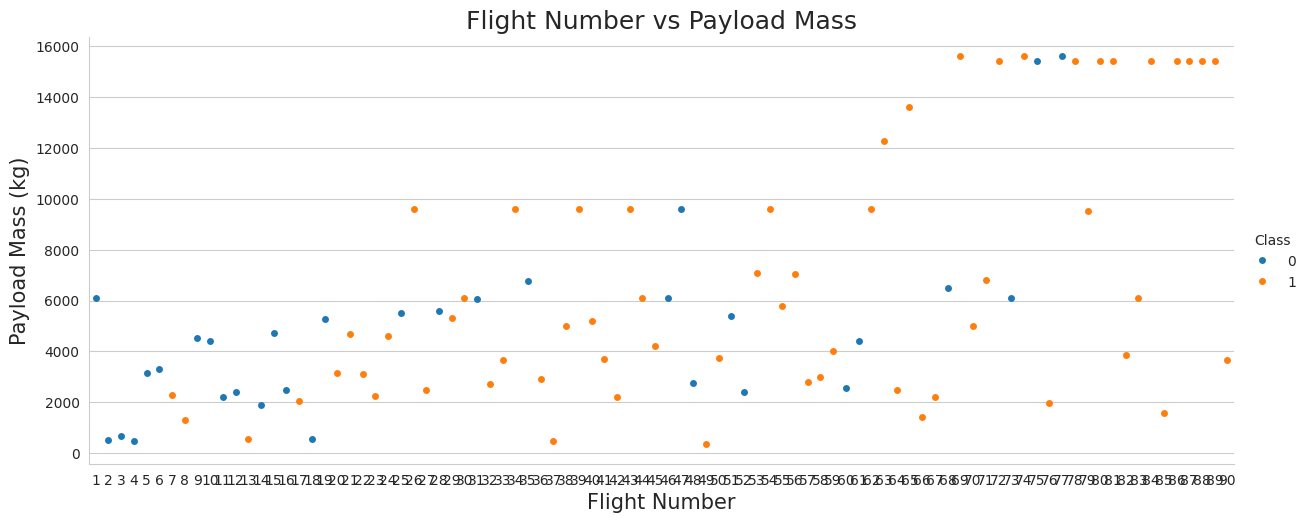


TASK 1: Flight Number vs Launch Site


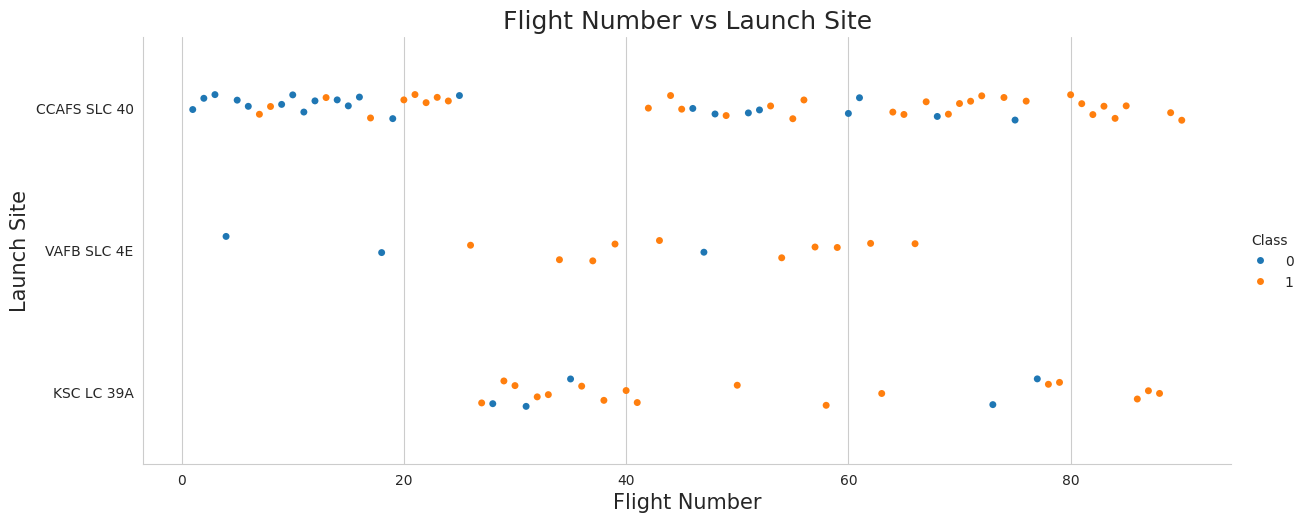


TASK 2: Payload Mass vs Launch Site


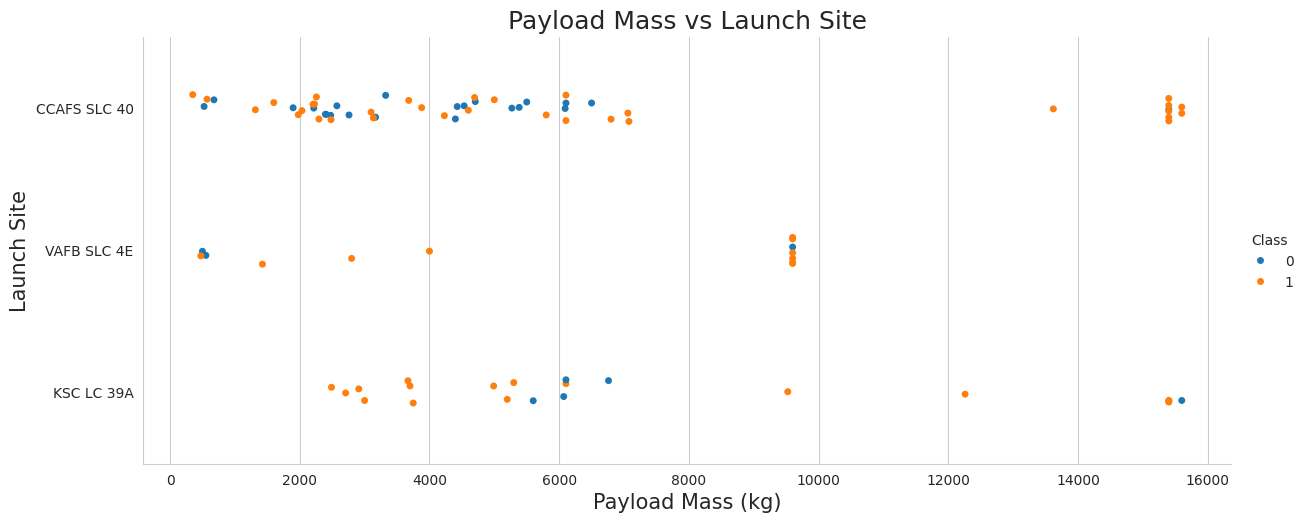


TASK 3: Success Rate by Orbit Type


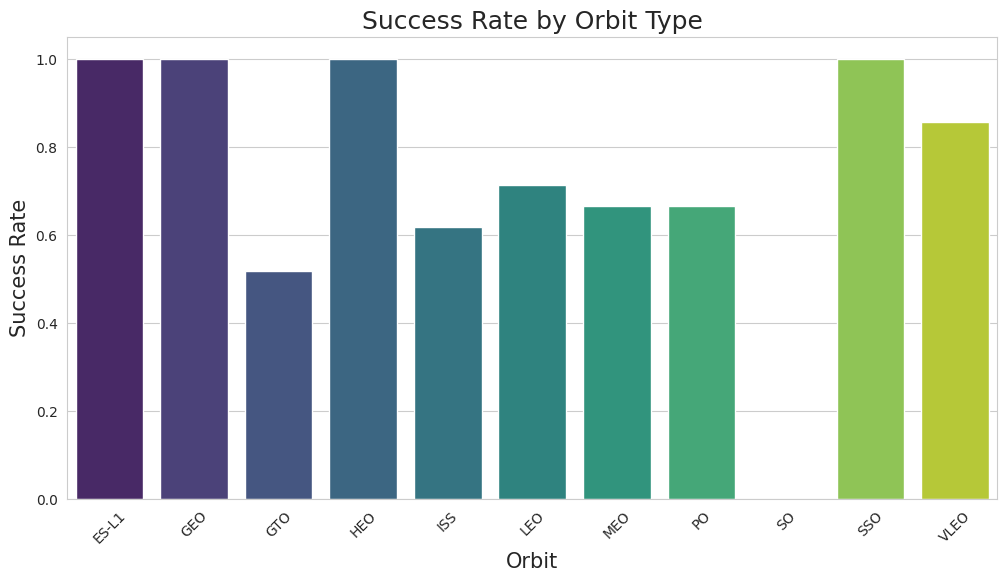


TASK 4: Flight Number vs Orbit


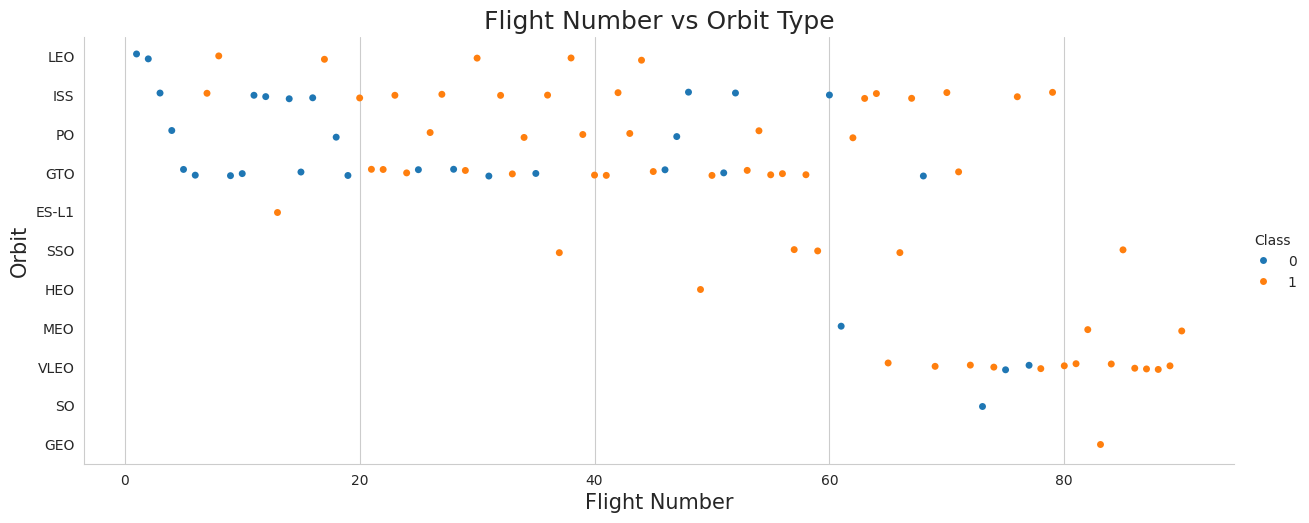


TASK 5: Payload Mass vs Orbit


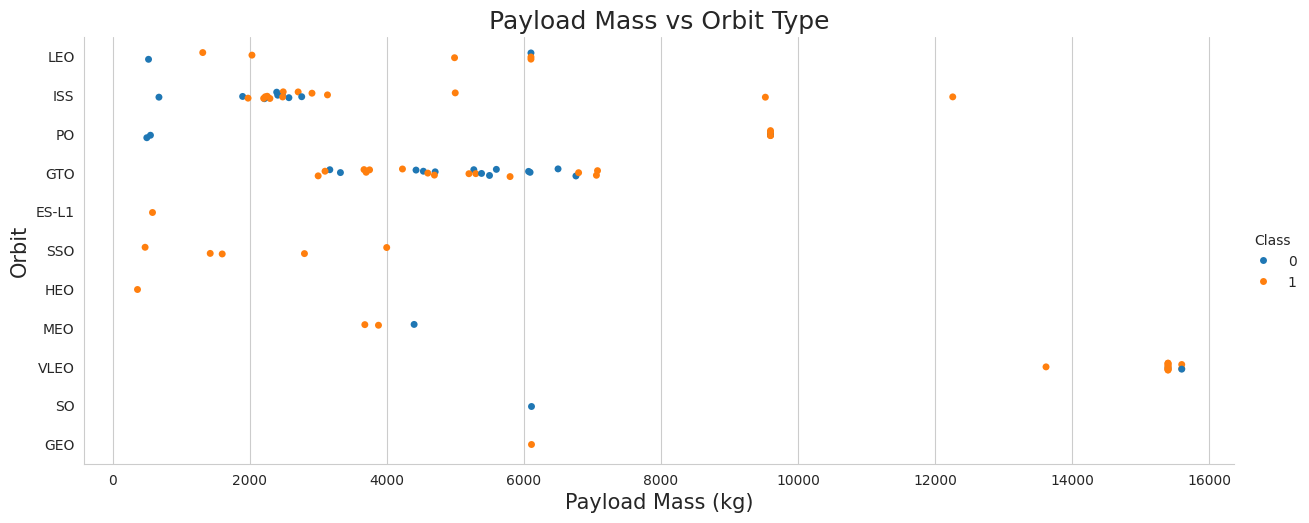


TASK 6: Yearly Launch Success Trend


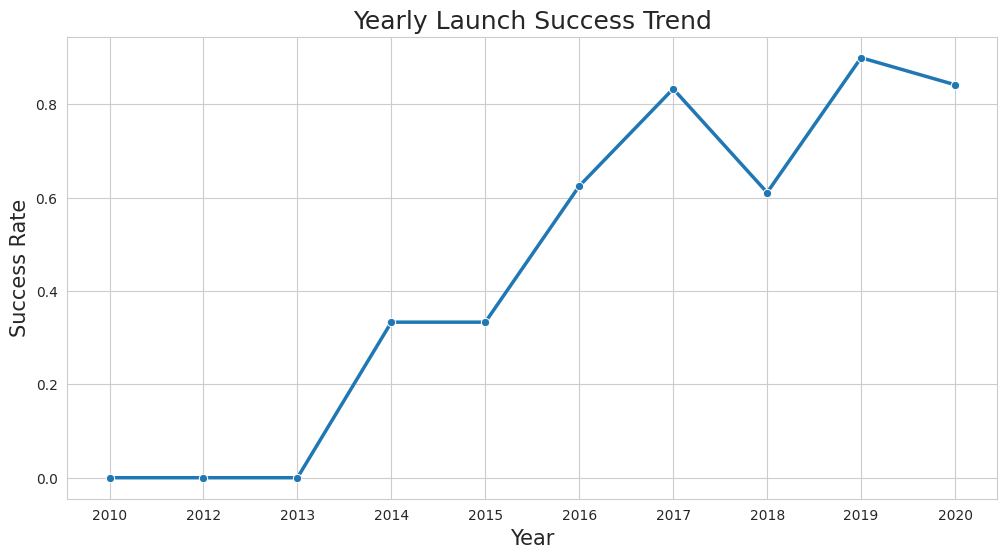


FEATURE ENGINEERING...

TASK 7: Creating dummy variables...
TASK 8: Converting to float64...

Dataset exported to 'dataset_part_3.csv'


In [ ]:

# INSTALL REQUIRED PACKAGES
!pip install pandas numpy seaborn matplotlib -q

# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SET PLOT STYLE
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("LOADING SPACEX DATASET...")

# LOAD DATASET
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
display(df.head())

# EXPLORATORY DATA ANALYSIS - VISUALIZATIONS

print("\nCREATING VISUALIZATIONS...")

# PLOT 1: Flight Number vs Payload Mass
print("\nPlot 1: Flight Number vs Payload Mass")
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=2.5)
plt.xlabel("Flight Number", fontsize=15)
plt.ylabel("Payload Mass (kg)", fontsize=15)
plt.title("Flight Number vs Payload Mass", fontsize=18)
plt.show()

# TASK 1: Flight Number vs Launch Site
print("\nTASK 1: Flight Number vs Launch Site")
sns.catplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, aspect=2.5)
plt.xlabel("Flight Number", fontsize=15)
plt.ylabel("Launch Site", fontsize=15)
plt.title("Flight Number vs Launch Site", fontsize=18)
plt.show()

# TASK 2: Payload Mass vs Launch Site
print("\nTASK 2: Payload Mass vs Launch Site")
sns.catplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df, aspect=2.5)
plt.xlabel("Payload Mass (kg)", fontsize=15)
plt.ylabel("Launch Site", fontsize=15)
plt.title("Payload Mass vs Launch Site", fontsize=18)
plt.show()

# TASK 3: Success Rate by Orbit Type
print("\nTASK 3: Success Rate by Orbit Type")
success_rate = df.groupby('Orbit')['Class'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x="Orbit", y="Class", data=success_rate, palette='viridis', hue="Orbit", legend=False)
plt.xlabel("Orbit", fontsize=15)
plt.ylabel("Success Rate", fontsize=15)
plt.title("Success Rate by Orbit Type", fontsize=18)
plt.xticks(rotation=45)
plt.show()

# TASK 4: Flight Number vs Orbit
print("\nTASK 4: Flight Number vs Orbit")
sns.catplot(x="FlightNumber", y="Orbit", hue="Class", data=df, aspect=2.5)
plt.xlabel("Flight Number", fontsize=15)
plt.ylabel("Orbit", fontsize=15)
plt.title("Flight Number vs Orbit Type", fontsize=18)
plt.show()

# TASK 5: Payload Mass vs Orbit
print("\nTASK 5: Payload Mass vs Orbit")
sns.catplot(x="PayloadMass", y="Orbit", hue="Class", data=df, aspect=2.5)
plt.xlabel("Payload Mass (kg)", fontsize=15)
plt.ylabel("Orbit", fontsize=15)
plt.title("Payload Mass vs Orbit Type", fontsize=18)
plt.show()

# TASK 6: Yearly Launch Success Trend
print("\nTASK 6: Yearly Launch Success Trend")
def Extract_year():
    year_list = []
    for i in df["Date"]:
        year_list.append(i.split("-")[0])
    return year_list

df["Year"] = Extract_year()
yearly_success = df.groupby('Year')['Class'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x="Year", y="Class", data=yearly_success, marker="o", linewidth=2.5)
plt.xlabel("Year", fontsize=15)
plt.ylabel("Success Rate", fontsize=15)
plt.title("Yearly Launch Success Trend", fontsize=18)
plt.grid(True)
plt.show()

# FEATURE ENGINEERING

print("\nFEATURE ENGINEERING...")

# Select features
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights',
               'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block',
               'ReusedCount', 'Serial']]

# TASK 7: Create dummy variables
print("\nTASK 7: Creating dummy variables...")
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])

# TASK 8: Cast to float64
print("TASK 8: Converting to float64...")
features_one_hot = features_one_hot.astype('float64')

# Export to CSV
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print("\nDataset exported to 'dataset_part_3.csv'")

Build an Interactive Map with Folium

In [ ]:

# INSTALL MISSING PACKAGES
!pip install folium wget pandas -q

# IBM DATA SCIENCE CAPSTONE - INTERACTIVE MAP WITH FOLIUM
import folium
import wget
import pandas as pd
from folium.plugins import MarkerCluster, MousePosition
from folium.features import DivIcon
from math import sin, cos, sqrt, atan2, radians

# 1. DATA LOADING
spacex_csv_file = wget.download('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv')
spacex_df = pd.read_csv(spacex_csv_file)
launch_sites_df = spacex_df.groupby(['Launch Site'], as_index=False).first()[['Launch Site', 'Lat', 'Long']]

# 2. INITIALIZE MAP
nasa_coordinate = [29.559684888503615, -95.0830971930759]
site_map = folium.Map(location=nasa_coordinate, zoom_start=5)

# 3. ADD TITLE
title_html = '''
             <h3 align="center" style="font-size:20px"><b>SpaceX Launch Site Proximity Analysis & Landing Success Rates</b></h3>
             '''
site_map.get_root().html.add_child(folium.Element(title_html))

# 4. TASK: MARK SITES & CLUSTERS
marker_cluster = MarkerCluster()
def assign_color(res): return 'green' if res == 1 else 'red'
spacex_df['marker_color'] = spacex_df['class'].apply(assign_color)

for index, row in launch_sites_df.iterrows():
    folium.Circle([row['Lat'], row['Long']], radius=1000, color='#0000FF', fill=True).add_to(site_map)
    folium.Marker([row['Lat'], row['Long']], icon=DivIcon(icon_size=(20,20), html='<div style="font-size: 12; color:#0000FF;"><b>%s</b></div>' % row['Launch Site'])).add_to(site_map)

for index, record in spacex_df.iterrows():
    marker_cluster.add_child(folium.Marker([record['Lat'], record['Long']], icon=folium.Icon(color='white', icon_color=record['marker_color'])))
site_map.add_child(marker_cluster)

# 5. TASK: DISTANCE CALCULATION
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6373.0
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon, dlat = lon2 - lon1, lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

launch_lat, launch_lon = 28.56230197, -80.57735648

proximities = {
    'Coastline': [28.56367, -80.56763],
    'Highway': [28.56321, -80.57079],
    'Railway': [28.57205, -80.58527],
    'City (Titusville)': [28.6122, -80.8075]
}

for name, coord in proximities.items():
    dist = calculate_distance(launch_lat, launch_lon, coord[0], coord[1])
    folium.Marker(coord, icon=DivIcon(icon_size=(20,20), html='<div style="font-size: 12; color:#d35400;"><b>%s: %.2f KM</b></div>' % (name, dist))).add_to(site_map)
    folium.PolyLine(locations=[[launch_lat, launch_lon], coord], weight=2, color='red').add_to(site_map)

site_map.add_child(MousePosition())

# SAVE AND DISPLAY
site_map.save('spacex_launch_map_final.html')
site_map

In [ ]:

# INSTALL REQUIRED PACKAGES
!pip install folium wget pandas -q

# IMPORT LIBRARIES
import folium
import wget
import pandas as pd
from folium.plugins import MarkerCluster
from folium.plugins import MousePosition
from folium.features import DivIcon
from math import sin, cos, sqrt, atan2, radians

print("BUILDING INTERACTIVE MAP WITH FOLIUM")

# TASK 1: MARK ALL LAUNCH SITES ON A MAP
print("\nTASK 1: Marking all launch sites on map...")

# Download and read the spacex_launch_geo.csv
spacex_csv_file = wget.download('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv')
spacex_df = pd.read_csv(spacex_csv_file)

# Select relevant sub-columns
spacex_df = spacex_df[['Launch Site', 'Lat', 'Long', 'class']]
launch_sites_df = spacex_df.groupby(['Launch Site'], as_index=False).first()
launch_sites_df = launch_sites_df[['Launch Site', 'Lat', 'Long']]

print(f"\nFound {len(launch_sites_df)} launch sites:")
print(launch_sites_df['Launch Site'].tolist())

# Create map centered at NASA Johnson Space Center
nasa_coordinate = [29.559684888503615, -95.0830971930759]
site_map = folium.Map(location=nasa_coordinate, zoom_start=5)

# Add circle and marker for each launch site
for index, row in launch_sites_df.iterrows():
    coordinate = [row['Lat'], row['Long']]
    launch_site_name = row['Launch Site']

    # Add circle
    circle = folium.Circle(
        coordinate,
        radius=1000,
        color='#0000FF',
        fill=True,
        fill_color='#0000FF'
    ).add_child(folium.Popup(launch_site_name))

    # Add marker with label
    marker = folium.Marker(
        coordinate,
        icon=DivIcon(
            icon_size=(20, 20),
            icon_anchor=(0, 0),
            html='<div style="font-size: 12; color:#0000FF;"><b>%s</b></div>' % launch_site_name
        )
    )

    site_map.add_child(circle)
    site_map.add_child(marker)

print("Launch sites marked on map")

# TASK 2: MARK SUCCESS/FAILED LAUNCHES FOR EACH SITE
print("\nTASK 2: Marking success/failed launches...")

# Create marker cluster
marker_cluster = MarkerCluster()

# Function to assign color based on launch outcome
def assign_marker_color(launch_outcome):
    if launch_outcome == 1:
        return 'green'
    else:
        return 'red'

# Add marker_color column
spacex_df['marker_color'] = spacex_df['class'].apply(assign_marker_color)

# Add markers to cluster
for index, record in spacex_df.iterrows():
    coordinate = [record['Lat'], record['Long']]
    marker = folium.Marker(
        coordinate,
        icon=folium.Icon(color='white', icon_color=record['marker_color'])
    )
    marker_cluster.add_child(marker)

# Add marker cluster to map
site_map.add_child(marker_cluster)

print("Success/failed launches marked with color-coded markers")

# TASK 3: CALCULATE DISTANCES TO PROXIMITIES
print("\nTASK 3: Calculating distances to proximities...")

# Haversine formula to calculate distance
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6373.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

# Add MousePosition to map
formatter = "function(num) {return L.Util.formatNum(num, 5);}; "
mouse_position = MousePosition(
    position='topright',
    separator=' Long: ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Lat:',
    lat_formatter=formatter,
    lng_formatter=formatter
)
site_map.add_child(mouse_position)

# CCAFS LC-40 coordinates
launch_site_lat = 28.56230197
launch_site_lon = -80.57735648

# Coastline coordinates (approximate)
coastline_lat = 28.56367
coastline_lon = -80.57163

distance_coastline = calculate_distance(
    launch_site_lat, launch_site_lon,
    coastline_lat, coastline_lon
)

print(f"\nCCAFS LC-40 to Coastline: {distance_coastline:.2f} km")

# Create and add distance marker
coastline_coordinate = [coastline_lat, coastline_lon]
distance_marker = folium.Marker(
    coastline_coordinate,
    icon=DivIcon(
        icon_size=(20, 20),
        icon_anchor=(0, 0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance_coastline)
    )
)
site_map.add_child(distance_marker)

# Draw polyline between launch site and coastline
lines = folium.PolyLine(
    locations=[[launch_site_lat, launch_site_lon], coastline_coordinate],
    weight=2,
    color='red'
)
site_map.add_child(lines)

# Example: Titusville
city_lat, city_lon = 28.6122, -80.8075
distance_city = calculate_distance(launch_site_lat, launch_site_lon, city_lat, city_lon)
print(f"CCAFS LC-40 to City (Titusville): {distance_city:.2f} km")

# DISPLAY AND SAVE MAP
print("\nInteractive map created successfully!")

# Save map to HTML file
site_map.save('spacex_launch_map.html')

# Display the map
site_map

BUILDING INTERACTIVE MAP WITH FOLIUM

TASK 1: Marking all launch sites on map...

Found 4 launch sites:
['CCAFS LC-40', 'CCAFS SLC-40', 'KSC LC-39A', 'VAFB SLC-4E']
Launch sites marked on map

TASK 2: Marking success/failed launches...
Success/failed launches marked with color-coded markers

TASK 3: Calculating distances to proximities...

CCAFS LC-40 to Coastline: 0.58 km
CCAFS LC-40 to City (Titusville): 23.15 km

Interactive map created successfully!


Build a Dashboard with Plotly Dash

In [ ]:

# Install required packages
!pip install pandas dash plotly wget -q

# Import required libraries
import pandas as pd
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import wget

print("Packages installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 97.9 MB/s eta 0:00:00
Packages installed successfully!


In [ ]:

# Download the SpaceX dataset
print("Downloading dataset...")
try:
    spacex_df = pd.read_csv("spacex_launch_dash.csv")
except:
    url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv"
    spacex_df = pd.read_csv(url)
    spacex_df.to_csv("spacex_launch_dash.csv", index=False)

print(f"Dataset loaded successfully!")
print(f"Shape: {spacex_df.shape}")
print(f"\nLaunch Sites: {spacex_df['Launch Site'].unique()}")

# Create the Dash app
app = dash.Dash(__name__)

# Define the app layout
app.layout = html.Div(children=[
    html.H1('SpaceX Launch Records Dashboard',
            style={'textAlign': 'center', 'color': '#503D36', 'font-size': 40}),

    # TASK 1: Launch Site Drop-down
    html.Div([
        html.Label("Select Launch Site:", style={'font-weight': 'bold', 'margin-bottom': 10}),
        dcc.Dropdown(
            id='site-dropdown',
            options=[
                {'label': 'All Sites', 'value': 'ALL'},
                {'label': 'CCAFS LC-40', 'value': 'CCAFS LC-40'},
                {'label': 'CCAFS SLC-40', 'value': 'CCAFS SLC-40'},
                {'label': 'KSC LC-39A', 'value': 'KSC LC-39A'},
                {'label': 'VAFB SLC-4E', 'value': 'VAFB SLC-4E'}
            ],
            value='ALL',
            placeholder="Select a Launch Site here",
            searchable=True,
            style={'width': '80%', 'margin': '0 auto'}
        )
    ], style={'margin-bottom': 30}),

    # TASK 2: Pie Chart
    html.Div([
        dcc.Graph(id='success-pie-chart')
    ], style={'margin-bottom': 30}),

    html.Div([
        html.P("Payload Range (kg):", style={'font-weight': 'bold', 'margin-bottom': 10}),
        # TASK 3: Range Slider
        dcc.RangeSlider(
            id='payload-slider',
            min=0,
            max=10000,
            step=1000,
            marks={0: '0', 2500: '2500', 5000: '5000', 7500: '7500', 10000: '10000'},
            value=[0, 10000],
            tooltip={"placement": "bottom", "always_visible": True}
        )
    ], style={'margin-bottom': 30, 'padding': '0 20px'}),

    # TASK 4: Scatter Chart
    html.Div([
        dcc.Graph(id='success-payload-scatter-chart')
    ])
], style={'padding': '20px', 'font-family': 'Arial'})

print("\nDash app created successfully!")

Dataset loaded successfully!
Shape: (56, 7)

Launch Sites: ['CCAFS LC-40' 'VAFB SLC-4E' 'KSC LC-39A' 'CCAFS SLC-40']

Dash app created successfully!


In [ ]:

import time
for i in range(5):
    print(f"Connection active... {i+1}")
    time.sleep(1)

Connection active... 1
Connection active... 2
Connection active... 3
Connection active... 4
Connection active... 5


In [ ]:

@app.callback(
    Output(component_id='success-pie-chart', component_property='figure'),
    Input(component_id='site-dropdown', component_property='value')
)
def get_pie_chart(entered_site):
    if entered_site == 'ALL':
        success_counts = spacex_df[spacex_df['class'] == 1]['Launch Site'].value_counts().reset_index()
        success_counts.columns = ['Launch Site', 'count']

        fig = px.pie(
            success_counts,
            values='count',
            names='Launch Site',
            title='Total Successful Launches for All Sites',
            color_discrete_sequence=px.colors.qualitative.Set3
        )
    else:
        site_data = spacex_df[spacex_df['Launch Site'] == entered_site]
        success_counts = site_data['class'].value_counts().reset_index()
        success_counts.columns = ['class', 'count']
        success_counts['Outcome'] = success_counts['class'].map({1: 'Success', 0: 'Failure'})

        fig = px.pie(
            success_counts,
            values='count',
            names='Outcome',
            title=f'Success vs Failure for {entered_site}',
            color_discrete_map={'Success': 'green', 'Failure': 'red'}
        )

    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.update_layout(height=500)
    return fig

@app.callback(
    Output(component_id='success-payload-scatter-chart', component_property='figure'),
    [
        Input(component_id='site-dropdown', component_property='value'),
        Input(component_id='payload-slider', component_property='value')
    ]
)
def update_scatter_chart(entered_site, payload_range):
    filtered_df = spacex_df[
        (spacex_df['Payload Mass (kg)'] >= payload_range[0]) &
        (spacex_df['Payload Mass (kg)'] <= payload_range[1])
    ]

    if entered_site == 'ALL':
        fig = px.scatter(
            filtered_df,
            x='Payload Mass (kg)',
            y='class',
            color='Booster Version Category',
            title='Correlation between Payload Mass and Launch Outcome for All Sites',
            labels={'class': 'Launch Outcome (1=Success, 0=Failure)'},
            hover_data=['Launch Site'],
            color_discrete_sequence=px.colors.qualitative.Plotly
        )
    else:
        filtered_df = filtered_df[filtered_df['Launch Site'] == entered_site]
        fig = px.scatter(
            filtered_df,
            x='Payload Mass (kg)',
            y='class',
            color='Booster Version Category',
            title=f'Correlation between Payload Mass and Launch Outcome for {entered_site}',
            labels={'class': 'Launch Outcome (1=Success, 0=Failure)'},
            hover_data=['Launch Site'],
            color_discrete_sequence=px.colors.qualitative.Plotly
        )

    fig.update_layout(height=500)
    return fig

print("Callback functions added successfully!")

Callback functions added successfully!


In [ ]:

# 1. Install & Import
!pip install dash pandas plotly -q
import pandas as pd
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
from google.colab import output

# 2. Load Data
spacex_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv")
min_payload = spacex_df['Payload Mass (kg)'].min()
max_payload = spacex_df['Payload Mass (kg)'].max()

# 3. Initialize App
app = dash.Dash(__name__)

# 4. Layout
app.layout = html.Div(children=[
    html.H1('SpaceX Launch Records Dashboard', style={'textAlign': 'center', 'color': '#503D36', 'font-size': 40}),
    dcc.Dropdown(id='site-dropdown',
                 options=[
                     {'label': 'All Sites', 'value': 'ALL'},
                     {'label': 'CCAFS LC-40', 'value': 'CCAFS LC-40'},
                     {'label': 'VAFB SLC-4E', 'value': 'VAFB SLC-4E'},
                     {'label': 'KSC LC-39A', 'value': 'KSC LC-39A'},
                     {'label': 'CCAFS SLC-40', 'value': 'CCAFS SLC-40'}
                 ],
                 value='ALL',
                 placeholder="Select a Launch Site here",
                 searchable=True),
    html.Br(),
    html.Div(dcc.Graph(id='success-pie-chart')),
    html.Br(),
    html.P("Payload range (Kg):"),
    dcc.RangeSlider(id='payload-slider',
                    min=0, max=10000, step=1000,
                    value=[min_payload, max_payload]),
    html.Div(dcc.Graph(id='success-payload-scatter-chart')),
])

# 5. Callbacks
@app.callback(Output(component_id='success-pie-chart', component_property='figure'),
              Input(component_id='site-dropdown', component_property='value'))
def get_pie_chart(entered_site):
    if entered_site == 'ALL':
        fig = px.pie(spacex_df, values='class', names='Launch Site', title='Total Success Launches By Site')
    else:
        filtered_df = spacex_df[spacex_df['Launch Site'] == entered_site]
        df_counts = filtered_df.groupby('class').size().reset_index(name='counts')
        fig = px.pie(df_counts, values='counts', names='class', title=f"Success vs Failure for {entered_site}")
    return fig

@app.callback(Output(component_id='success-payload-scatter-chart', component_property='figure'),
              [Input(component_id='site-dropdown', component_property='value'),
               Input(component_id='payload-slider', component_property='value')])
def update_scatter(entered_site, payload_range):
    low, high = payload_range
    mask = (spacex_df['Payload Mass (kg)'] >= low) & (spacex_df['Payload Mass (kg)'] <= high)
    filtered_df = spacex_df[mask]
    if entered_site == 'ALL':
        fig = px.scatter(filtered_df, x="Payload Mass (kg)", y="class", color="Booster Version Category", title="Payload vs. Success (All Sites)")
    else:
        site_df = filtered_df[filtered_df['Launch Site'] == entered_site]
        fig = px.scatter(site_df, x="Payload Mass (kg)", y="class", color="Booster Version Category", title=f"Payload vs. Success for {entered_site}")
    return fig

# 6. Run App
public_url = output.eval_js("google.colab.kernel.proxyPort(8050)")
print(f"URL: {public_url}")
app.run(jupyter_mode='external', port=8050)

URL: https://8050-m-s-kkb-use4c0-10n4mi72r42sd-c.us-east4-0.prod.colab.dev
Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [19/Mar/2026 16:42:17] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [19/Mar/2026 16:42:18] "GET /_dash-component-suites/dash/deps/polyfill@7.v4_0_0m1773938182.12.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [19/Mar/2026 16:42:18] "GET /_dash-component-suites/dash/deps/react@18.v4_0_0m1773938182.3.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [19/Mar/2026 16:42:18] "GET /_dash-component-suites/dash/deps/react-dom@18.v4_0_0m1773938182.3.1.min.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [19/Mar/2026 16:42:18] "GET /_dash-component-suites/dash/dcc/dash_core_components.v4_0_0m1773938182.js HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [19/Mar/2026 16:42:18] "GET /_dash-component-suites/dash/dcc/dash_core_components-shared.v4_0_0m1773938182.j

In [ ]:

# 1. Install & Import
!pip install dash pandas plotly -q
import pandas as pd
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
from google.colab import output

# 2. Load Data
spacex_df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv")
min_payload = spacex_df['Payload Mass (kg)'].min()
max_payload = spacex_df['Payload Mass (kg)'].max()

# 3. Initialize App
app = dash.Dash(__name__)

# 4. Layout
app.layout = html.Div(children=[
    html.H1('SpaceX Launch Records Dashboard',
            style={'textAlign': 'center', 'color': '#503D36', 'font-size': 35}),

    # TASK 1: Dropdown
    dcc.Dropdown(id='site-dropdown',
                 options=[
                     {'label': 'All Sites', 'value': 'ALL'},
                     {'label': 'CCAFS LC-40', 'value': 'CCAFS LC-40'},
                     {'label': 'VAFB SLC-4E', 'value': 'VAFB SLC-4E'},
                     {'label': 'KSC LC-39A', 'value': 'KSC LC-39A'},
                     {'label': 'CCAFS SLC-40', 'value': 'CCAFS SLC-40'}
                 ],
                 value='ALL',
                 placeholder="Select a Launch Site here",
                 searchable=True),
    html.Br(),

    # TASK 2: Pie Chart
    html.Div(dcc.Graph(id='success-pie-chart')),
    html.Br(),

    # TASK 3: Range Slider
    html.P("Payload range (Kg):", style={'font-weight': 'bold'}),
    dcc.RangeSlider(id='payload-slider',
                    min=0, max=10000, step=1000,
                    marks={0: '0', 2500: '2500', 5000: '5000', 7500: '7500', 10000: '10000'},
                    value=[min_payload, max_payload]),

    # TASK 4: Scatter Chart
    html.Div(dcc.Graph(id='success-payload-scatter-chart')),
])

# 5. Callbacks
@app.callback(Output(component_id='success-pie-chart', component_property='figure'),
              Input(component_id='site-dropdown', component_property='value'))
def get_pie_chart(entered_site):
    if entered_site == 'ALL':
        fig = px.pie(spacex_df, values='class',
                     names='Launch Site',
                     title='Total Success Launches By Site')
    else:
        filtered_df = spacex_df[spacex_df['Launch Site'] == entered_site]
        df_counts = filtered_df.groupby('class').size().reset_index(name='counts')
        df_counts['Outcome'] = df_counts['class'].map({1: 'Success', 0: 'Failure'})
        fig = px.pie(df_counts, values='counts',
                     names='Outcome',
                     title=f"Success vs Failure for {entered_site}",
                     color='Outcome',
                     color_discrete_map={'Success': '#2ca02c', 'Failure': '#d62728'})
    return fig

@app.callback(Output(component_id='success-payload-scatter-chart', component_property='figure'),
              [Input(component_id='site-dropdown', component_property='value'),
               Input(component_id='payload-slider', component_property='value')])
def update_scatter(entered_site, payload_range):
    low, high = payload_range
    mask = (spacex_df['Payload Mass (kg)'] >= low) & (spacex_df['Payload Mass (kg)'] <= high)
    filtered_df = spacex_df[mask]
    if entered_site == 'ALL':
        fig = px.scatter(filtered_df, x="Payload Mass (kg)", y="class",
                         color="Booster Version Category",
                         title="Payload vs. Success (All Sites)",
                         labels={'class': 'Launch Outcome (1=Success, 0=Failure)'})
    else:
        site_df = filtered_df[filtered_df['Launch Site'] == entered_site]
        fig = px.scatter(site_df, x="Payload Mass (kg)", y="class",
                         color="Booster Version Category",
                         title=f"Payload vs. Success for {entered_site}",
                         labels={'class': 'Launch Outcome (1=Success, 0=Failure)'})
    return fig

# 6. Run App with Colab Proxy Fix
if __name__ == '__main__':
    # Map port 8999 to a public URL
    public_url = output.eval_js("google.colab.kernel.proxyPort(8999)")
    print(f"\n🚀 SUCCESS! CLICK THIS LINK TO VIEW DASHBOARD:")
    print(f"{public_url}\n")

    # Run server on port 8999
    app.run(jupyter_mode='external', port=8999)


🚀 SUCCESS! CLICK THIS LINK TO VIEW DASHBOARD:
https://8999-m-s-kkb-use4c0-10n4mi72r42sd-c.us-east4-0.prod.colab.dev

Dash is running on http://127.0.0.1:8999/



INFO:dash.dash:Dash is running on http://127.0.0.1:8999/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8999
INFO:werkzeug:Press CTRL+C to quit


In [ ]:

# 1. Install & Import
!pip install plotly pandas ipywidgets -q

import pandas as pd
import plotly.express as px
import plotly.io as pio
from ipywidgets import interact, widgets

# ✅ CRITICAL FIX FOR COLAB:
pio.renderers.default = "colab"

# 2. Load Data
spacex_df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv"
)

min_payload = spacex_df['Payload Mass (kg)'].min()
max_payload = spacex_df['Payload Mass (kg)'].max()
launch_sites = ['ALL'] + sorted(spacex_df['Launch Site'].unique())

# 3. Function to update dashboard
def update_dashboard(site='ALL', payload_range=(min_payload, max_payload)):
    low, high = payload_range

    df_filtered = spacex_df[(spacex_df['Payload Mass (kg)'] >= low) &
                             (spacex_df['Payload Mass (kg)'] <= high)]

    # Pie Chart
    if site == 'ALL':
        fig_pie = px.pie(df_filtered[df_filtered['class']==1],
                         values='class',
                         names='Launch Site',
                         title='Total Success Launches By Site')
    else:
        df_site = df_filtered[df_filtered['Launch Site'] == site]
        df_counts = df_site.groupby('class').size().reset_index(name='counts')
        df_counts['Outcome'] = df_counts['class'].map({1: 'Success', 0: 'Failure'})
        fig_pie = px.pie(df_counts, values='counts', names='Outcome',
                         title=f'Success vs Failure for {site}')

    # Scatter Plot
    if site != 'ALL':
        df_filtered = df_filtered[df_filtered['Launch Site'] == site]

    fig_scatter = px.scatter(df_filtered,
                             x='Payload Mass (kg)',
                             y='class',
                             color='Booster Version Category',
                             title=f'Payload vs Success')

    # Display the figures
    fig_pie.show()
    fig_scatter.show()

# 4. Create widgets
site_widget = widgets.Dropdown(options=launch_sites, value='ALL', description='Launch Site:')
payload_widget = widgets.FloatRangeSlider(
    value=[min_payload, max_payload],
    min=min_payload,
    max=max_payload,
    step=500,
    description='Payload (kg)',
    continuous_update=False
)

# 5. Display interactive dashboard
interact(update_dashboard, site=site_widget, payload_range=payload_widget);

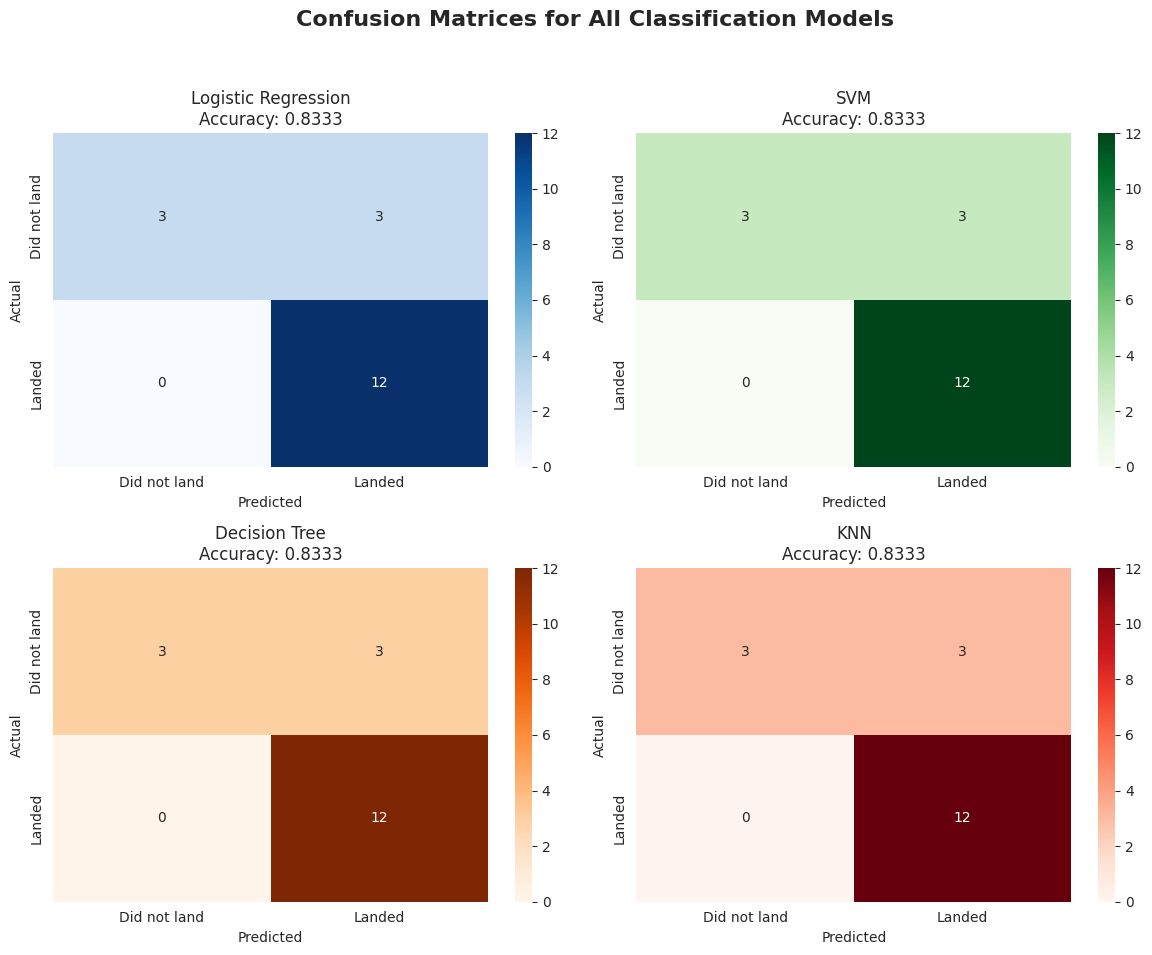

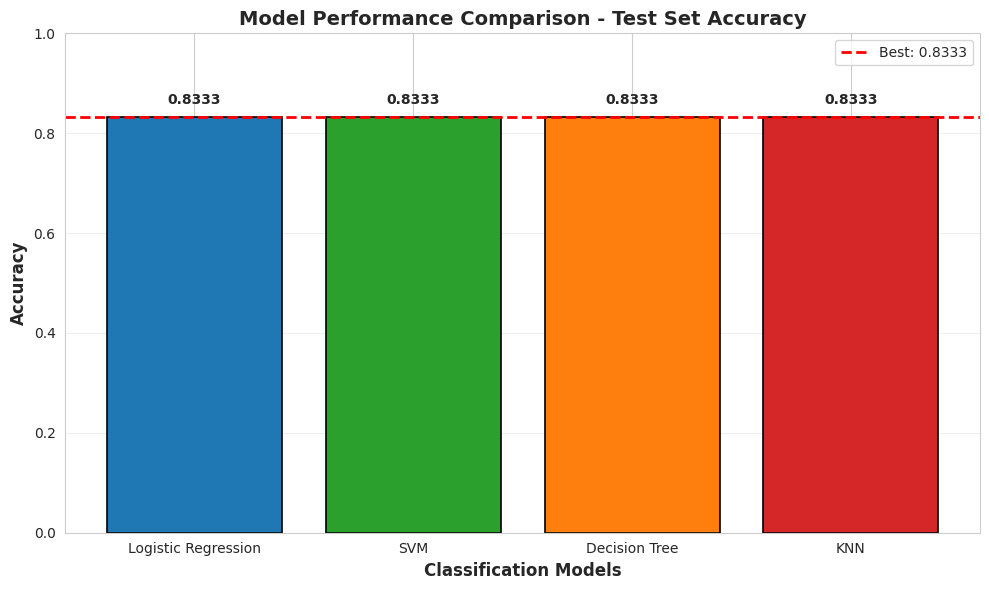

In [ ]:

# INSTALL REQUIRED PACKAGES
!pip install numpy pandas seaborn scikit-learn matplotlib -q

# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# LOAD THE DATA
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")
X = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv")

# TASK 1: Create NumPy array from Class column
Y = data['Class'].to_numpy()

# TASK 2: Standardize the data
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# TASK 3: Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

# TASK 4: Logistic Regression with GridSearchCV
parameters = {'C':[0.01, 0.1, 1],
              'penalty':['l2'],
              'solver':['lbfgs']}

lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

# TASK 5: Calculate accuracy on test data
logreg_test_accuracy = logreg_cv.score(X_test, Y_test)
yhat_lr = logreg_cv.predict(X_test)
cm_lr = confusion_matrix(Y_test, yhat_lr)

# TASK 6: Support Vector Machine with GridSearchCV
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}

svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)

# TASK 7: Calculate accuracy on test data
svm_test_accuracy = svm_cv.score(X_test, Y_test)
yhat_svm = svm_cv.predict(X_test)
cm_svm = confusion_matrix(Y_test, yhat_svm)

# TASK 8: Decision Tree with GridSearchCV
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2*n for n in range(1,10)],
              'max_features': ['sqrt'],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)

# TASK 9: Calculate accuracy on test data
tree_test_accuracy = tree_cv.score(X_test, Y_test)
yhat_tree = tree_cv.predict(X_test)
cm_tree = confusion_matrix(Y_test, yhat_tree)

# TASK 10: K-Nearest Neighbors with GridSearchCV
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)

# TASK 11: Calculate accuracy on test data
knn_test_accuracy = knn_cv.score(X_test, Y_test)
yhat_knn = knn_cv.predict(X_test)
cm_knn = confusion_matrix(Y_test, yhat_knn)

# TASK 12: Find the best performing model
models = {
    'Logistic Regression': logreg_test_accuracy,
    'SVM': svm_test_accuracy,
    'Decision Tree': tree_test_accuracy,
    'KNN': knn_test_accuracy
}

best_model = max(models, key=models.get)
best_accuracy = models[best_model]

# VISUALIZATION: Plot all confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices for All Classification Models', fontsize=16, fontweight='bold')
labels = ['Did not land', 'Landed']

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', ax=axes[0,0], cmap='Blues', xticklabels=labels, yticklabels=labels)
axes[0,0].set_title(f'Logistic Regression\nAccuracy: {logreg_test_accuracy:.4f}')

# SVM
sns.heatmap(cm_svm, annot=True, fmt='d', ax=axes[0,1], cmap='Greens', xticklabels=labels, yticklabels=labels)
axes[0,1].set_title(f'SVM\nAccuracy: {svm_test_accuracy:.4f}')

# Decision Tree
sns.heatmap(cm_tree, annot=True, fmt='d', ax=axes[1,0], cmap='Oranges', xticklabels=labels, yticklabels=labels)
axes[1,0].set_title(f'Decision Tree\nAccuracy: {tree_test_accuracy:.4f}')

# KNN
sns.heatmap(cm_knn, annot=True, fmt='d', ax=axes[1,1], cmap='Reds', xticklabels=labels, yticklabels=labels)
axes[1,1].set_title(f'KNN\nAccuracy: {knn_test_accuracy:.4f}')

for ax in axes.flat:
    ax.set(xlabel='Predicted', ylabel='Actual')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# VISUALIZATION: Bar chart of model accuracies
plt.figure(figsize=(10, 6))
model_names = list(models.keys())
accuracies = list(models.values())
colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', linewidth=1.2)
plt.xlabel('Classification Models', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison - Test Set Accuracy', fontsize=14, fontweight='bold')
plt.ylim([0, 1.0])
plt.axhline(y=best_accuracy, color='red', linestyle='--', linewidth=2, label=f'Best: {best_accuracy:.4f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()